In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score


In [ ]:
train = pd.read_csv("/content/drive/MyDrive/train (9).csv")
weather = pd.read_csv("/content/drive/MyDrive/weather_train.csv")
building = pd.read_csv("/content/drive/MyDrive/building_metadata.csv")

print("Train shape:", train.shape)
print("Weather shape:", weather.shape)
print("Building shape:", building.shape)


Train shape: (2045271, 4)
Weather shape: (139773, 9)
Building shape: (1449, 6)


In [ ]:
df = train.merge(building, on="building_id", how="left")

df = df.merge(weather, on=["site_id", "timestamp"], how="left")

print("Merged shape:", df.shape)
print(df.columns)


Merged shape: (2045271, 16)
Index(['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id',
       'primary_use', 'square_feet', 'year_built', 'floor_count',
       'air_temperature', 'cloud_coverage', 'dew_temperature',
       'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction',
       'wind_speed'],
      dtype='object')


In [ ]:
df = df[df["meter"] == 0]

In [ ]:
# Remove extremely high outliers
df = df[df["meter_reading"] < 5000]

# Convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Create time features
df["hour"] = df["timestamp"].dt.hour
df["month"] = df["timestamp"].dt.month

# Forward fill missing values
df = df.fillna(method="ffill")


/tmp/ipykernel_331/1575981328.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


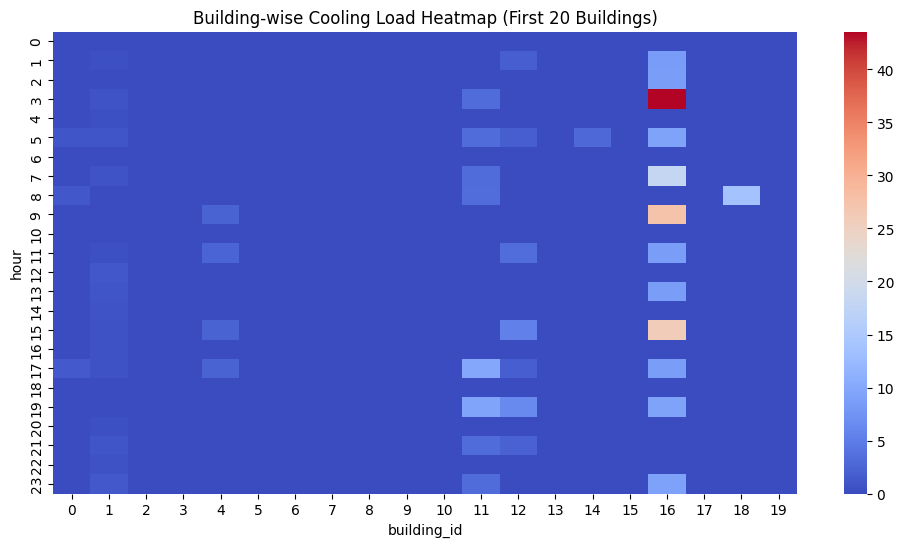

In [ ]:
heatmap_data = df.pivot_table(
    values="meter_reading",
    index="hour",
    columns="building_id",
    aggfunc="mean"
)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data.iloc[:, :20], cmap="coolwarm")
plt.title("Building-wise Cooling Load Heatmap (First 20 Buildings)")
plt.show()


In [ ]:
features = [
    "square_feet",
    "year_built",
    "air_temperature",
    "cloud_coverage",
    "dew_temperature",
    "wind_speed",
    "hour",
    "month"
]

X = df[features]
y = df["meter_reading"]


X = X.dropna()
y = y.loc[X.index]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
model = DecisionTreeRegressor(max_depth=12, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))


MAE: 41.97947458403433
R2 Score: 0.910263950245111


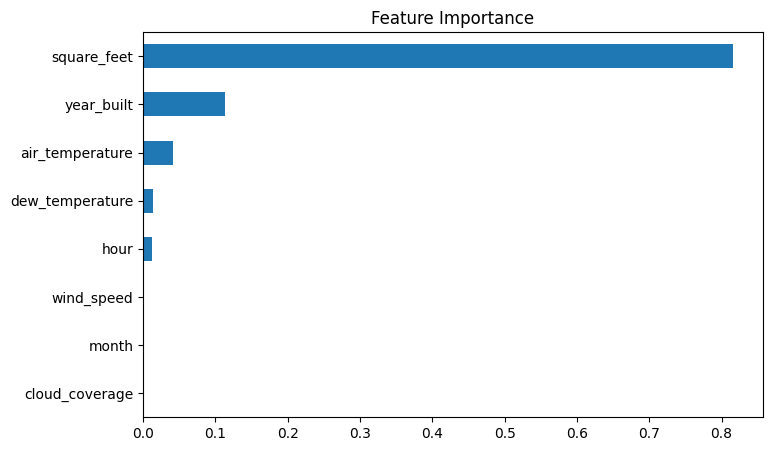

In [ ]:
importance = pd.Series(model.feature_importances_, index=features)

plt.figure(figsize=(8,5))
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()


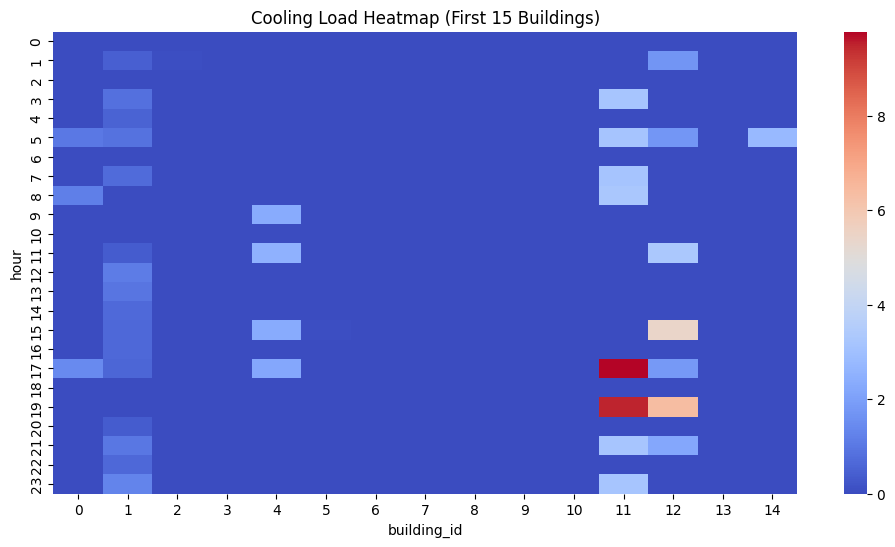

In [ ]:
heatmap_data = df.pivot_table(
    values="meter_reading",
    index="hour",
    columns="building_id",
    aggfunc="mean"
)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data.iloc[:, :15], cmap="coolwarm")
plt.title("Cooling Load Heatmap (First 15 Buildings)")
plt.show()
